In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.tensor([1.0, 2.0]) @ torch.tensor([3.0, 4.0]))


2.13.0
False
tensor(11.)


PROBLEM 1

In [2]:
x = torch.tensor([[[1., 2., 3.],
                    [4., 5., 6.],
                    [7., 8., 9.],
                    [10.,11.,12.]],
                  [ [2., 4., 6.],
                    [1., 3., 5.],
                    [8.,10.,12.],
                    [7., 9.,11.]]])
y = torch.tensor([[1, 0, 1, 0], [0, 1, 1, 1]])

mask = y.unsqueeze(-1)
masked_x = x*mask
num = masked_x.sum(dim=1)
den = mask.sum(dim=1)
num/den

tensor([[4.0000, 5.0000, 6.0000],
        [5.3333, 7.3333, 9.3333]])

PROBLEM 2

In [3]:
x = torch.tensor([1.0, 2.0, 3.0])
exp_x = torch.exp(x)
output = exp_x / torch.sum(exp_x)
softmax = torch.softmax(x, dim=-1)

print("Manual Softmax :", output)
print("Torch Softmax  :", softmax)

Manual Softmax : tensor([0.0900, 0.2447, 0.6652])
Torch Softmax  : tensor([0.0900, 0.2447, 0.6652])


PROBLEM 3

In [4]:
# Example Q and K
# B = 1
# T = 2
# d = 3



Q = torch.tensor([[[1., 2., 3.],
                   [4., 5., 6.]]])



K = torch.tensor([[[7., 8., 9.],
                   [10., 11., 12.]]])

scores = Q @ K.transpose(-2, -1)
einsum_scores = torch.einsum("bik,bjk->bij",Q,K)

print("Manual Scores :", scores)
print("Einsum Scores  :", einsum_scores)

Manual Scores : tensor([[[ 50.,  68.],
         [122., 167.]]])
Einsum Scores  : tensor([[[ 50.,  68.],
         [122., 167.]]])


PROBLEM 4

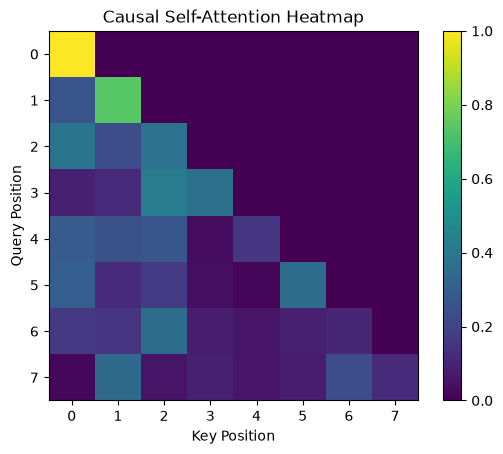

In [5]:
import matplotlib.pyplot as plt

T = 8

# random scores
scores = torch.randn(T, T)

# Create causal mask
mask = torch.triu(torch.ones(T, T), diagonal=1)
mask = mask.masked_fill(mask == 1, float('-inf'))

# mask
masked_scores = scores + mask

# Softmax
attention = torch.softmax(masked_scores, dim=-1)

# Plot heatmap
plt.imshow(attention, cmap='viridis')
plt.colorbar()

plt.title("Causal Self-Attention Heatmap")
plt.xlabel("Key Position")
plt.ylabel("Query Position")

plt.show()

PROBLEM 5

In [6]:
import torch.nn as nn

# input
B, T, C = 2, 4, 8
x = torch.randn(B, T, C)

# epsilon
eps = 1e-5

mean = x.mean(dim=-1, keepdim=True)
var = x.var(dim=-1, keepdim=True, unbiased=False)
# keepdim as we dont drop the C dimension

x_hat = (x - mean) / torch.sqrt(var + eps) # normalise

gamma = torch.ones(C)
beta = torch.zeros(C)

out = gamma * x_hat + beta

print(out.shape)

ln = nn.LayerNorm(C)

# copy parameters
ln.weight.data = gamma
ln.bias.data = beta

output = ln(x)

print(torch.allclose(out, output, atol=1e-5))

torch.Size([2, 4, 8])
True


PROBLEM 6


In [7]:
x = torch.randn(4, requires_grad=True)
y = (x**2).sum()
y.backward()

print(x)
print(x.grad) # derivative of x^2 which is 2x

x = torch.randn(4, requires_grad=True)
y = torch.softmax(x, dim=0).sum()
y.backward()
print(x.grad)

tensor([-0.5172,  0.7801,  0.5979, -0.1463], requires_grad=True)
tensor([-1.0344,  1.5602,  1.1957, -0.2925])
tensor([0., 0., 0., 0.])


softmax(x).sum() = 1 which is a constant.


since the derivative of a constant is zero

hence the output becomes zero.